# Hierarchical binary inference across filters

We often have multiple datasets with different telescopes or wavelengths, and it is useful to be able to treat a shared scene geometry with different fluxes at different wavelengths, for example; this is the principle behind (say) [SPARCO](https://arxiv.org/abs/1403.3343), where objects in the scene are allowed to have different SEDs.

Here is a simple example where we fit a binary model to three interferometric observations simultaneously, taken at three different wavelengths. The binary position is shared between filters, while each filter has its own flux ratio.

Many of the ideas in this notebook are explored in greater detail [in the Zodiax docs](https://louisdesdoigts.github.io/zodiax/optimisation_tools/) - check them out!

In [1]:
import sys
from pathlib import Path

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as onp
import numpyro
import numpyro.distributions as dist
import optimistix as optx
import pandas as pd
from jax.flatten_util import ravel_pytree
from numpyro.infer import MCMC, NUTS
from numpyro.infer.initialization import init_to_value

jax.config.update("jax_enable_x64", True)

repo_root = Path.cwd()
if not (repo_root / "src").exists():
    repo_root = repo_root.parent
for path in (repo_root, repo_root / "src"):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from drpangloss.inference import (
    fisher_projection,
    gaussian_fisher,
    observed_information,
    regularized_inverse,
)
from drpangloss.models import (
    BinaryModelCartesian,
    joint_data,
    joint_errors,
    joint_loglike,
    joint_prediction,
)
from drpangloss.plotting import (
    plot_chainconsumer_diagnostics,
    plot_data_model_correlation,
    plot_likelihood_grid,
    posterior_predictive_summary,
)
from examples.hierarchical_binary_workflow import (
    FILTER_LABELS,
    simulate_observations,
)

## Simulate three observations

The three `OIData` objects have the same baseline sampling and uncertainties but wavelengths of 800 nm, 1.0 micron, and 1.2 microns.

In [2]:
observations, truth = simulate_observations(seed=7)

{
    label: {
        "wavelength_m": float(observation.wavel[0]),
        "n_observables": int(observation.flatten_data()[0].size),
        "flux_ratio": float(10.0 ** truth["log10_flux"][index]),
    }
    for index, (label, observation) in enumerate(
        zip(FILTER_LABELS, observations)
    )
}

{'800 nm': {'wavelength_m': 8e-07,
  'n_observables': 36,
  'flux_ratio': 0.014999999999999996},
 '1.0 micron': {'wavelength_m': 1e-06,
  'n_observables': 36,
  'flux_ratio': 0.010000000000000005},
 '1.2 microns': {'wavelength_m': 1.2e-06,
  'n_observables': 36,
  'flux_ratio': 0.007000000000000002}}

## Define the hierarchy

A hierarchical model is easily expressed by an ordinary JAX pytree. The astrometry is shared, while indexing the flux vector selects a parameter unique to each observation. This is the same model-building pattern used by Zodiax: parameters remain separate from the objects that describe each observation.

In [3]:
params = {
    "dra": jnp.array(15.0),
    "ddec": jnp.array(-9.0),
    "log10_flux": jnp.log10(jnp.array([0.012, 0.012, 0.012])),
}


def binary_model(values, observation_index):
    return BinaryModelCartesian(values["dra"],values["ddec"],
                                10.0 ** values["log10_flux"][observation_index])


initial_loglike = joint_loglike(params, observations, binary_model)
truth_loglike = joint_loglike(truth, observations, binary_model)

print(f"initial log-likelihood: {float(initial_loglike)}, optimal: {float(truth_loglike)}")

initial log-likelihood: -5654.122745306354, optimal: 682.2989893515032


## Joint grid initialization

Before fitting independent fluxes in each filter, we search a compact grid in shared right ascension, declination, and flux. The best shared-flux point provides a robust starting position and initializes every filter flux for the hierarchical optimization and HMC steps.

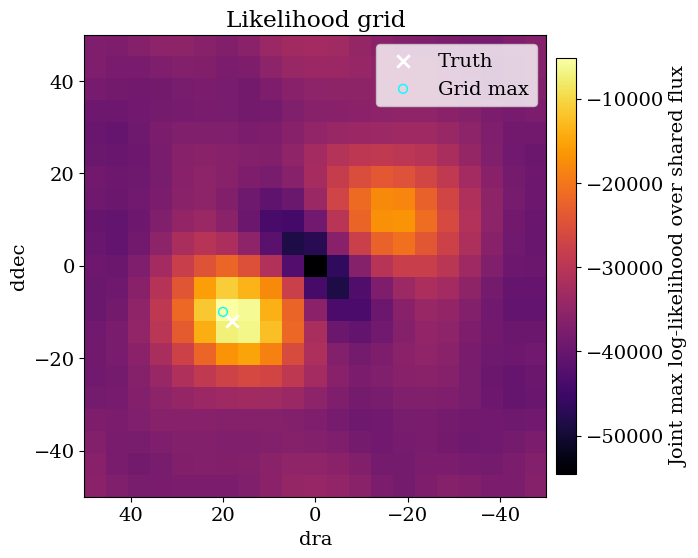

In [4]:
joint_grid_samples = {
    "dra": jnp.linspace(-50.0, 50.0, 21),
    "ddec": jnp.linspace(-50.0, 50.0, 21),
    "flux": 10.0 ** jnp.linspace(-4.0, -1.0, 16),
}
joint_grid_axes = jnp.meshgrid(*joint_grid_samples.values(), indexing="ij")
joint_grid_values = jnp.stack([axis.reshape(-1) for axis in joint_grid_axes], axis=1)

def shared_flux_loglike(values):
    shared_params = {
        "dra": values[0],
        "ddec": values[1],
        "log10_flux": jnp.full(
            len(observations), jnp.log10(values[2]), dtype=values.dtype)
            }
    return joint_loglike(shared_params, observations, binary_model)


joint_grid_loglike = jax.vmap(shared_flux_loglike)(joint_grid_values).reshape(
    tuple(axis.size for axis in joint_grid_samples.values()))
joint_grid_index = jnp.unravel_index(
    jnp.argmax(joint_grid_loglike), joint_grid_loglike.shape)
joint_grid_best = {
    name: float(joint_grid_samples[name][index])
    for name, index in zip(joint_grid_samples, joint_grid_index)}

plot_likelihood_grid(
    joint_grid_loglike.max(axis=2),
    joint_grid_samples,
    truths={"dra": float(truth["dra"]), "ddec": float(truth["ddec"])},
    best_point=joint_grid_best,
    colorbar_label="Joint max log-likelihood over shared flux",)

params = {
    "dra": jnp.array(joint_grid_best["dra"]),
    "ddec": jnp.array(joint_grid_best["ddec"]),
    "log10_flux": jnp.full(
        len(observations), jnp.log10(joint_grid_best["flux"])
    ),
}


## Preconditioning before Inference

The Fisher Information Matrix tells us the expected information in the data, providing both a limit to the best possible covariance we can obtain from the data (the Cramér-Rao lower bound) and a way of normalising parameters, which might have very different scales and correlations. It is often best to do this normalization before Bayesian inference, in order to precondition the model for fast convergence. 

In [5]:
prediction_fn = lambda values: joint_prediction(values, observations, binary_model)
errors = joint_errors(observations)
initial_fisher, unravel = gaussian_fisher(prediction_fn, params, errors, ridge=1e-8)
projection = fisher_projection(initial_fisher, eps=1e-10)

print(f"Fisher matrix: {initial_fisher.shape[0]} x {initial_fisher.shape[1]}")

Fisher matrix: 5 x 5


## Optimization

The Fisher matrix defines well-scaled local coordinates. We optimize in those coordinates, then map the result back to the physical parameter tree.

In [6]:
initial_vector, unravel = ravel_pytree(params)


def project(latent):
    # project a latent vector back to the original space
    return unravel(initial_vector + projection @ latent)

def latent_objective(latent, args) :
    return -joint_loglike(project(latent), observations, binary_model)

solver = optx.BestSoFarMinimiser(optx.BFGS(rtol=1e-8, atol=1e-8))
solution = optx.minimise(
    latent_objective,
    solver,
    jnp.zeros_like(initial_vector),
    max_steps=256,
    throw=False,
)
recovered = project(solution.value)

initial_chi2r = jnp.sum(((joint_data(observations) - prediction_fn(params)) / errors) ** 2) / (
    errors.size - initial_vector.size
)
final_chi2r = jnp.sum(((joint_data(observations) - prediction_fn(recovered)) / errors) ** 2) / (
    errors.size - initial_vector.size
)
print(f"Reduced chi-squared: {float(initial_chi2r):.2f} -> {float(final_chi2r):.2f}")

Reduced chi-squared: 113.66 -> 0.89


In [7]:
recovered_vector, recovered_unravel = ravel_pytree(recovered)

def flat_objective(values):
    return -joint_loglike(recovered_unravel(values), observations, binary_model)


expected_fisher, _ = gaussian_fisher(prediction_fn, recovered, errors)
observed_info = observed_information(flat_objective, recovered_vector)
laplace_covariance = regularized_inverse(observed_info, ridge=1e-8)
laplace_sigma = jnp.sqrt(jnp.diag(laplace_covariance))

parameter_names = ["ddec (mas)", "dra (mas)"] + [f"log10 flux ({label})" for label in FILTER_LABELS]
pd.DataFrame(
    {"estimate": onp.asarray(recovered_vector), "Laplace sigma": onp.asarray(laplace_sigma)},
    index=parameter_names,
)

,estimate,Laplace sigma
ddec (mas),-11.928194,0.048962
dra (mas),17.962123,0.048782
log10 flux (800 nm),-1.826236,0.001678
log10 flux (1.0 micron),-1.998476,0.002590
log10 flux (1.2 microns),-2.154878,0.004064


## Interpreting the local covariance

The table above comes from the Hessian of the negative log likelihood at the optimum. It is a local Laplace approximation, which we compare with HMC below.

## Hamiltonian Monte Carlo

The same shared-position, per-filter-flux parameter tree can be sampled with NumPyro. We initialize HMC from the joint grid maximum used by the optimizer.

In [8]:
def model_hmc():
    dra = numpyro.sample("dra", dist.Uniform(-30.0, 30.0)) # uniform prior in cartesian coordinates
    ddec = numpyro.sample("ddec", dist.Uniform(-30.0, 30.0))
    log10_flux = numpyro.sample(
        "log10_flux", dist.Uniform(-6.0, -1.0).expand([len(observations)])
    ) # uniform prior for the fluxes in log space, ie jeffreys prior
    values = {"dra": dra, "ddec": ddec, "log10_flux": log10_flux}
    numpyro.factor("loglike", joint_loglike(values, observations, binary_model))

init_values = {
    "dra": float(params["dra"]),
    "ddec": float(params["ddec"]),
    "log10_flux": params["log10_flux"],
}
# HMC with no U-turn sampler
kernel = NUTS(model_hmc, init_strategy=init_to_value(values=init_values)) 
mcmc = MCMC(
    kernel, num_warmup=800, num_samples=2000, num_chains=1, progress_bar=False
)
mcmc.run(jax.random.PRNGKey(2026))
posterior = mcmc.get_samples()

print(f"Posterior RA {jnp.median(posterior['dra']):.2f}, \
      Dec {jnp.median(posterior['ddec']):.2f}")
for index, name in enumerate(FILTER_LABELS):
    print(f"{name} Flux: {jnp.median(10.0 ** posterior['log10_flux'][:, index]):.4f}")

Posterior RA 17.96,       Dec -11.93
800 nm Flux: 0.0149
1.0 micron Flux: 0.0100
1.2 microns Flux: 0.0070


## Corner plot of shared and per-filter parameters

Let's visualize the recovered parameters and compare them to the truth values from which they are simulated:

Parameter ddec (mas) in chain HMC is not constrained


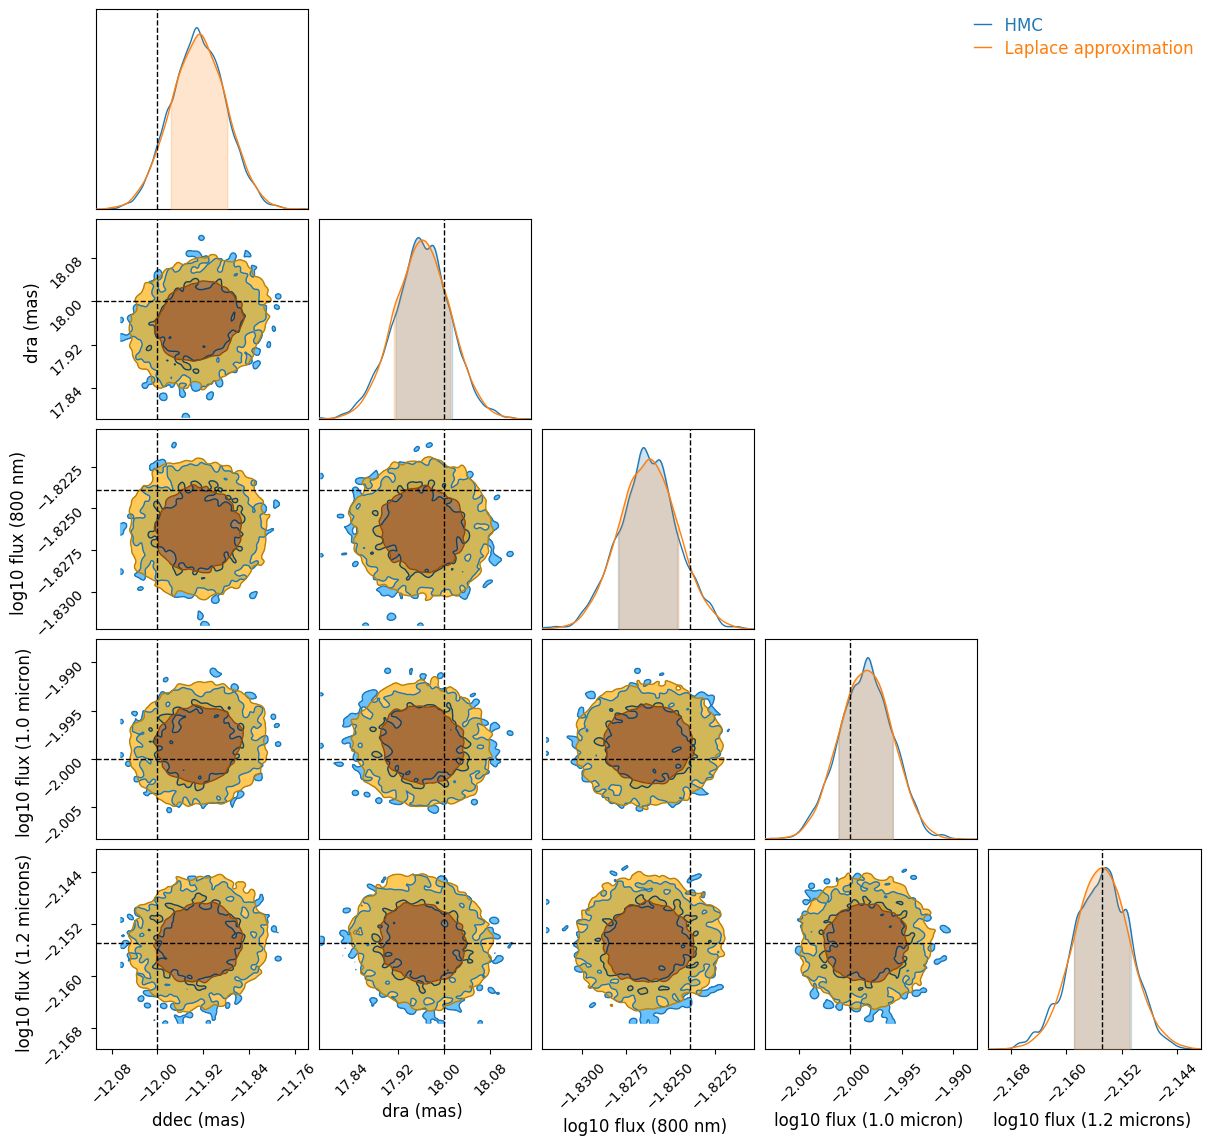

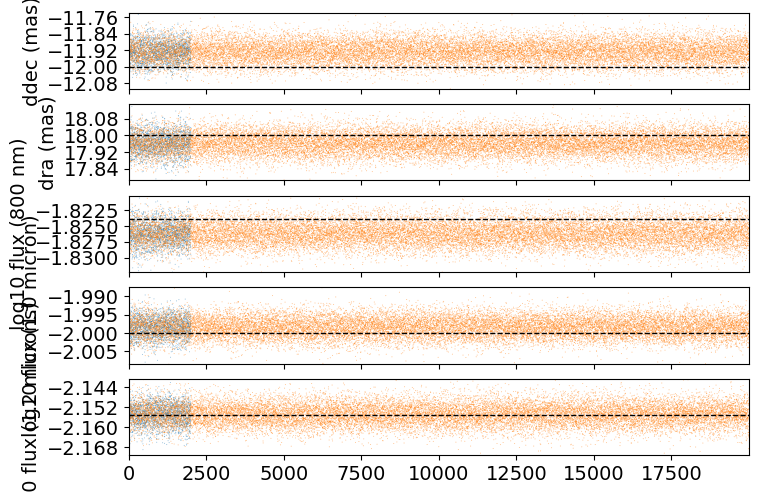

In [9]:
parameter_columns = ["ddec (mas)", "dra (mas)"] + [f"log10 flux ({label})" for label in FILTER_LABELS]

flat_recovered, unravel_recovered = ravel_pytree(recovered)
flat_truth, _ = ravel_pytree(truth)
n_samples = 20000
cholesky = jnp.linalg.cholesky(laplace_covariance)
standard_normal = jax.random.normal(jax.random.PRNGKey(11), (n_samples, flat_recovered.size))
latent_samples = flat_recovered[None, :] + standard_normal @ cholesky.T
laplace_samples_df = pd.DataFrame(onp.asarray(latent_samples), columns=parameter_columns)

hmc_samples_df = pd.DataFrame(
    {
        "ddec (mas)": onp.asarray(posterior["ddec"]),
        "dra (mas)": onp.asarray(posterior["dra"]),
        **{
            f"log10 flux ({label})": onp.asarray(posterior["log10_flux"][:, index])
            for index, label in enumerate(FILTER_LABELS)
        },
    }
)
truth_dict = dict(zip(parameter_columns, onp.asarray(flat_truth)))

plot_chainconsumer_diagnostics(
    {"HMC": hmc_samples_df, "Laplace approximation": laplace_samples_df},
    columns=parameter_columns,
    truth=truth_dict,
    colors=["#1f77b4", "#ff7f0e"],
)

## Posterior predictive correlation per filter

As always, we check the fit against the data directly rather than trusting the corner plot alone. Each filter has its own flux, so we build one data-vs-model correlation plot per observation using the shared astrometry samples paired with that filter's flux samples.

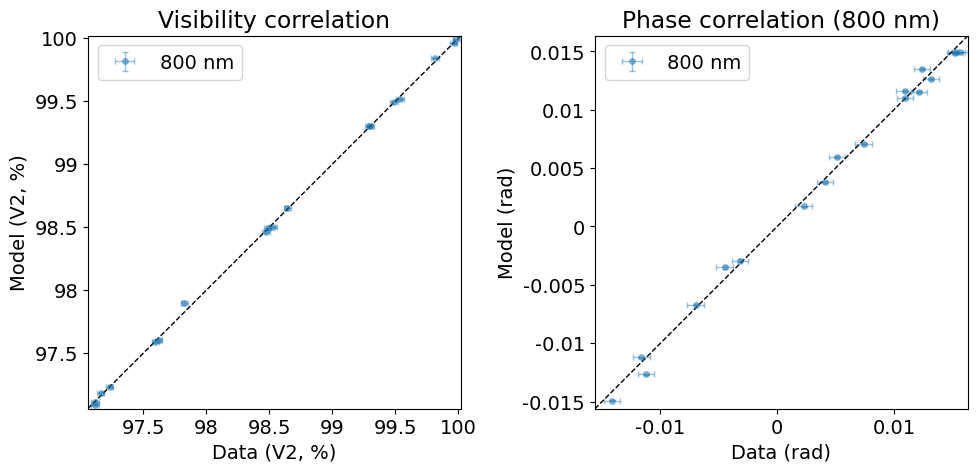

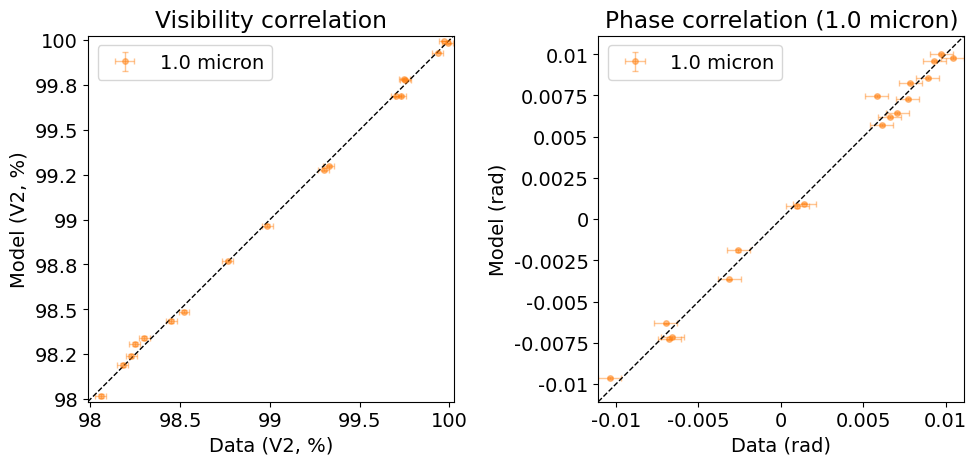

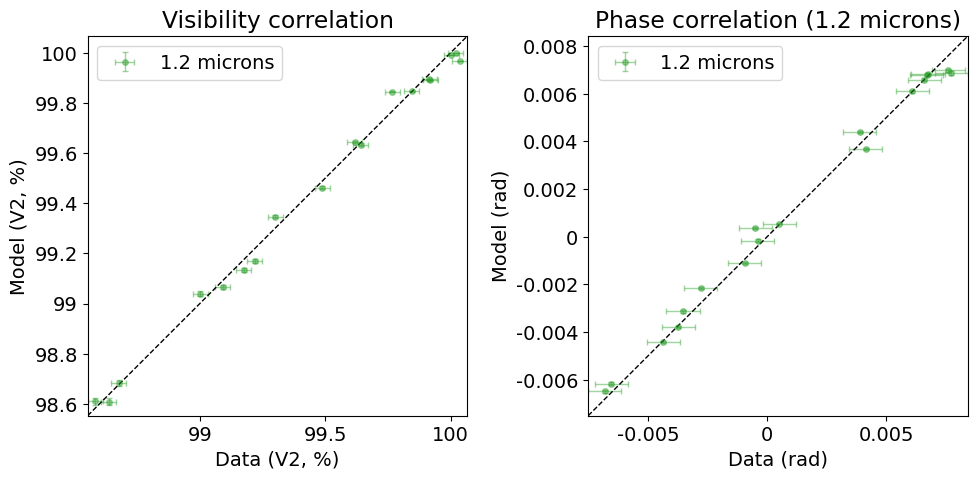

In [10]:
# Subsample the Laplace draws for the (slower, per-sample) posterior predictive check.
predictive_samples = jax.vmap(unravel_recovered)(latent_samples[:500])

for index, (label, observation) in enumerate(zip(FILTER_LABELS, observations)):
    predicted = posterior_predictive_summary(
        onp.asarray(predictive_samples["dra"]),
        onp.asarray(predictive_samples["ddec"]),
        onp.asarray(10.0 ** predictive_samples["log10_flux"][:, index]),
        observation,
        BinaryModelCartesian,
    )
    plot_data_model_correlation(
        observation,
        {label: predicted},
        colors=[f"C{index}"],
        phase_title=f"Phase correlation ({label})",
    )
    plt.show()

## Visibility and phase versus baseline

Finally, we look at visibility amplitude and phase directly as a function of baseline length, one column per filter. Because the three observations share the same array geometry, the baseline lengths are identical; only the flux, and therefore the fitted amplitude and phase, differ between filters.

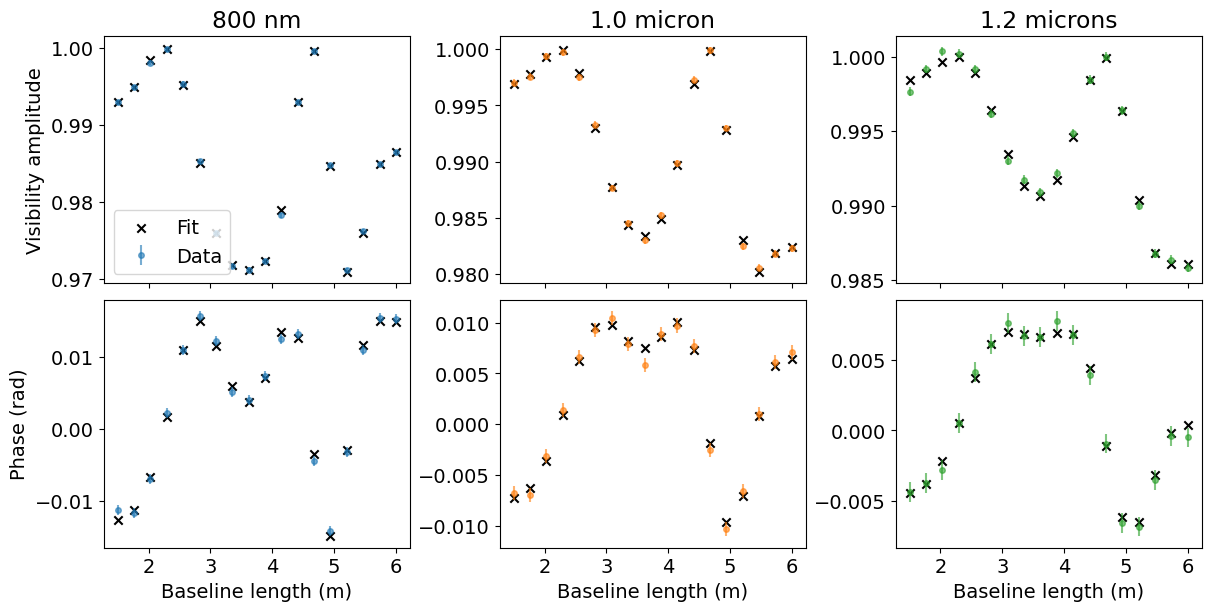

In [11]:
fig, axes = plt.subplots(
    2, 3, figsize=(12, 6), sharex=True, constrained_layout=True
)

for index, (label, observation) in enumerate(zip(FILTER_LABELS, observations)):
    baseline = jnp.sqrt(observation.u**2 + observation.v**2)
    cvis_fit = binary_model(recovered, index).model(
        observation.u, observation.v, observation.wavel
    )
    vis_fit = observation.to_vis(cvis_fit)
    phi_fit = observation.to_phases(cvis_fit)

    ax_vis, ax_phi = axes[0, index], axes[1, index]
    ax_vis.errorbar(
        baseline,
        observation.vis,
        yerr=observation.d_vis,
        fmt="o",
        markersize=4,
        alpha=0.6,
        color=f"C{index}",
        label="Data",
    )
    ax_vis.scatter(baseline, vis_fit, marker="x", color="k", label="Fit")
    ax_vis.set_title(label)

    ax_phi.errorbar(
        baseline,
        observation.phi,
        yerr=observation.d_phi,
        fmt="o",
        markersize=4,
        alpha=0.6,
        color=f"C{index}",
    )
    ax_phi.scatter(baseline, phi_fit, marker="x", color="k")
    ax_phi.set_xlabel("Baseline length (m)")

axes[0, 0].set_ylabel("Visibility amplitude")
axes[1, 0].set_ylabel("Phase (rad)")
axes[0, 0].legend(loc="best")
plt.show()